In [1]:
import pandas as pd

filepath = "GSE93272_series_matrix.txt"

meta = {}
with open(filepath, "r") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")
            first_val = parts[1].strip('"')
            if ":" in first_val:
                key = first_val.split(":")[0].strip()
                values = []
                for p in parts[1:]:
                    p = p.strip('"')
                    if ":" in p:
                        values.append(p.split(":", 1)[1].strip())
                    else:
                        values.append(None)
                meta[key] = values
        elif line.startswith("!Sample_source_name_ch1"):
            parts = line.strip().split("\t")
            meta["source"] = [p.strip('"') for p in parts[1:]]

df = pd.DataFrame(meta)
print(f"✓ {len(df)} hasta, {len(df.columns)} sütun yüklendi")

✓ 275 hasta, 37 sütun yüklendi


In [2]:
df.head(20)

,source,individual id,disease state,tissue,batch,rin,age,gender,cdai,kowabari,...,sjs38,rf,ccp,ana,ifx_days,ifx.ir_days,mtx_days,mtx.ir_days,tcz_days,tcz.ir_days
0,Whole blood from healthy control,HC003,healthy control,whole blood,1,7.6,45,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,Whole blood from healthy control,HC004,healthy control,whole blood,1,8.5,40,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,Whole blood from healthy control,HC005,healthy control,whole blood,1,8.3,54,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,Whole blood from healthy control,HC006,healthy control,whole blood,1,8.1,50,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,Whole blood from healthy control,HC007,healthy control,whole blood,1,7.3,31,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,Whole blood from healthy control,HC008,healthy control,whole blood,1,7.4,44,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,Whole blood from healthy control,HC009,healthy control,whole blood,1,7,43,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
7,Whole blood from healthy control,HC010,healthy control,whole blood,1,7.6,25,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
8,Whole blood from healthy control,HC011,healthy control,whole blood,1,7.4,29,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
9,Whole blood from healthy control,HC012,healthy control,whole blood,1,7.4,38,F,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [3]:
df.columns.tolist()

['source',
 'individual id',
 'disease state',
 'tissue',
 'batch',
 'rin',
 'age',
 'gender',
 'cdai',
 'kowabari',
 'haq',
 'd.vas',
 'pain.vas',
 'symptom.vas',
 'tjc66.68',
 'sjc66.68',
 'crp.das28',
 'esr.das28',
 'crp',
 'esr',
 'mmp3',
 'hras38',
 'acr',
 'sdai',
 'tjc28',
 'sjc28',
 'tjc38',
 'sjs38',
 'rf',
 'ccp',
 'ana',
 'ifx_days',
 'ifx.ir_days',
 'mtx_days',
 'mtx.ir_days',
 'tcz_days',
 'tcz.ir_days']

In [4]:
# Sadece RA hastalarını al
ra = df[df["disease state"] == "RA"].copy()

# Sayısala çevir
sayisal = ["age", "cdai", "haq", "d.vas", "pain.vas", "kowabari", "tjc66.68"]
for col in sayisal:
    ra[col] = pd.to_numeric(ra[col], errors="coerce")

print(f"RA hasta sayısı: {len(ra)}")
print(f"\nNA sayıları:")
print(ra[sayisal].isna().sum())
print(f"\nÖzet istatistik:")
ra[sayisal].describe()

RA hasta sayısı: 232

NA sayıları:
age         0
cdai        1
haq         0
d.vas       0
pain.vas    1
kowabari    0
tjc66.68    0
dtype: int64

Özet istatistik:


,age,cdai,haq,d.vas,pain.vas,kowabari,tjc66.68
count,232.000000,231.000000,232.000000,232.000000,231.000000,232.000000,232.000000
mean,57.185345,13.122511,0.830280,21.982759,37.744589,274.818966,5.193966
std,14.703569,12.472760,0.735672,20.397132,27.457155,489.143949,7.098037
min,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,52.000000,4.500000,0.250000,7.000000,12.000000,0.000000,1.000000
50%,59.000000,10.000000,0.750000,16.000000,34.000000,55.000000,2.000000
75%,68.000000,17.000000,1.125000,31.000000,60.000000,180.000000,6.250000
max,82.000000,68.400000,2.875000,98.000000,100.000000,1440.000000,48.000000


In [5]:
ra.head(20)

,source,individual id,disease state,tissue,batch,rin,age,gender,cdai,kowabari,...,sjs38,rf,ccp,ana,ifx_days,ifx.ir_days,mtx_days,mtx.ir_days,tcz_days,tcz.ir_days
30,Whole blood from rheumatoid arthritis,R060,RA,whole blood,1,8.2,60,F,37.8,120,...,24,8.96578428466209,8.59618975614441,5.32192809488736,NA,0,NA,NA,NA,NA
31,Whole blood from rheumatoid arthritis,R022,RA,whole blood,1,8.5,78,F,13.3,240,...,2,1.32192809488736,-1.73696559416621,7.32192809488736,NA,NA,NA,0,NA,NA
32,Whole blood from rheumatoid arthritis,R003,RA,whole blood,1,8.4,62,F,13.4,30,...,6,6.78135971352466,6.05961485629722,5.32192809488736,NA,NA,NA,NA,NA,NA
33,Whole blood from rheumatoid arthritis,R008,RA,whole blood,1,8.2,39,F,9.6,0,...,6,8.83920378809694,8.22881869049588,7.32192809488736,NA,NA,NA,NA,NA,NA
34,Whole blood from rheumatoid arthritis,R028,RA,whole blood,1,8.5,27,F,32.5,0,...,24,7.33091687811462,8.68999797141945,5.32192809488736,NA,NA,NA,NA,NA,NA
35,Whole blood from rheumatoid arthritis,R002,RA,whole blood,1,8.5,71,F,9.2,180,...,3,6.58496250072116,6.64385618977472,7.32192809488736,NA,NA,NA,NA,NA,NA
36,Whole blood from rheumatoid arthritis,R046,RA,whole blood,1,8,61,F,18.4,180,...,6,5.93073733756289,4.0703893278914,4.32192809488736,NA,NA,NA,NA,NA,NA
37,Whole blood from rheumatoid arthritis,R029,RA,whole blood,1,8.9,52,F,14.6,1440,...,11,3.70043971814109,5.19377174339668,4.32192809488736,NA,NA,0,NA,NA,NA
38,Whole blood from rheumatoid arthritis,R034,RA,whole blood,1,8.6,52,M,16.4,360,...,16,7.68650052718322,0.925999418556223,4.32192809488736,NA,NA,NA,0,NA,NA
39,Whole blood from rheumatoid arthritis,R004,RA,whole blood,1,8.7,44,F,52.8,40,...,31,1.32192809488736,3.71149490665009,6.32192809488736,NA,NA,NA,NA,NA,NA


Peki bu hasta tedaviye yanıt verir mi ,vermez mi?
Bunun için hedef değişkeni oluşturmamız lazım. CDAI skoru bunu bize söylüyor.
Tedaviye yanıt :
 CDAI başlangıçta yüksek, tedavi sonrası düşük.
 Yanıtsızlık = CDAI yüksek kalmaya devam ediyor.

CDIA:

0-2.8 → Remisyon
2.9-10 → Düşük aktivite
10.1-22 → Orta aktivite
22+ → Yüksek aktivite

Sayısal veriler kullanacağız kadınlar ve erkeklerdeki tedaviye yanıt farklılığı için F=1,M=0 alıyoruz.

In [6]:
# Sadece RA, sayısala çevir
sayisal = ["age", "cdai", "haq", "d.vas", "pain.vas", "kowabari", "tjc66.68"]
for col in sayisal:
    ra[col] = pd.to_numeric(ra[col], errors="coerce")

# Cinsiyet sayısala çevir
ra["gender_num"] = (ra["gender"] == "F").astype(int)

# Hedef değişken: CDAI > 10 ise aktif hastalık (yanıt yok = 1)
ra["hedef"] = (ra["cdai"] > 10).astype(int)

print("Hedef dağılımı:")
print(ra["hedef"].value_counts())
print(f"\n0 = Yanıt var (CDAI ≤ 10): {(ra['hedef']==0).sum()} hasta")
print(f"1 = Yanıt yok (CDAI > 10): {(ra['hedef']==1).sum()} hasta")

Hedef dağılımı:
hedef
0    117
1    115
Name: count, dtype: int64

0 = Yanıt var (CDAI ≤ 10): 117 hasta
1 = Yanıt yok (CDAI > 10): 115 hasta


Modelde 1 her zaman "kötü olan şeyi" veya "tahmin etmek istediğin olayı" temsil eder.
Biz ne tahmin etmek istiyoruz? "Bu hasta tedaviye yanıt vermeyecek mi?"
Yani asıl soru bu — yanıtsızlık riskini tespit etmek istiyoruz. O yüzden:
1 = Yanıt YOK (tehlikeli durum, doktorun bilmesi gereken şey)
0 = Yanıt VAR (iyi durum, endişe yok)

Tersini yapsaydık ne olurdu?
Olurdu, model çalışırdı. Ama o zaman model "yanıt var olasılığı" hesaplardı. Biz "direnç riski" hesaplamak istiyoruz — yani 1'in olasılığını.
hedef=yanıt vermeyenlerrrr

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# CDAI olmadan feature listesi
features = ["age", "haq", "d.vas", "pain.vas", "kowabari", "tjc66.68", "gender_num"]

model_df = ra[features + ["hedef"]].dropna()
print(f"Model için kullanılacak hasta sayısı: {len(model_df)}")

X = model_df[features]
y = model_df["hedef"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n=== MODEL SONUÇLARI ===")
print(classification_report(y_test, y_pred))
print(f"AUROC: {roc_auc_score(y_test, y_prob):.3f}")

Model için kullanılacak hasta sayısı: 231

=== MODEL SONUÇLARI ===
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        24
           1       0.88      0.91      0.89        23

    accuracy                           0.89        47
   macro avg       0.89      0.89      0.89        47
weighted avg       0.89      0.89      0.89        47

AUROC: 0.935


c:\Users\Sıla\Desktop\Romato\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


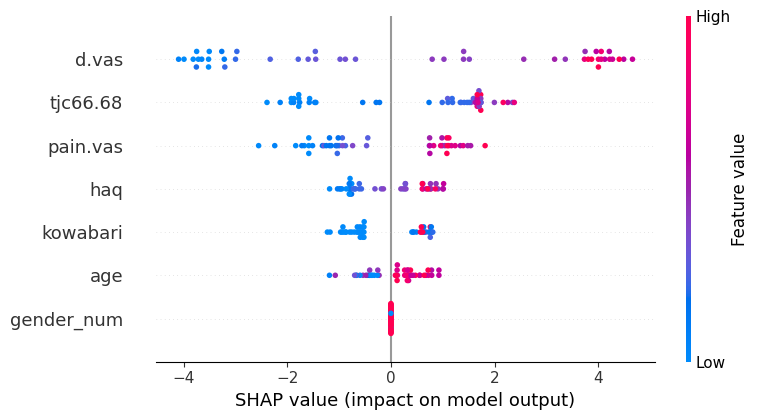

<Figure size 640x480 with 0 Axes>

In [8]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import os

klasor = r"C:\Users\Sıla\Desktop\Romato\temp_extract"
dosyalar = sorted([f for f in os.listdir(klasor) if f.endswith(".txt")])

# Her dosyayı oku, GSM ID'yi sütun adı yap
ornekler = {}
for dosya in dosyalar:
    gsm_id = dosya.replace("_sample_table.txt", "")
    yol = os.path.join(klasor, dosya)
    tmp = pd.read_csv(yol, sep="\t", index_col=0)  # df değil tmp — orijinal df korunur
    tmp.columns = [gsm_id]
    ornekler[gsm_id] = tmp

# Hepsini birleştir (gen × örnek matrisi)
matris = pd.concat(ornekler.values(), axis=1)
matris.index.name = "Gen"

print(f"Matris boyutu: {matris.shape[0]} gen × {matris.shape[1]} örnek")
print(f"Boş değer oranı: %{matris.isna().sum().sum() / matris.size * 100:.1f}")
print("\nİlk 10 satır:")
matris.head(10)

Matris boyutu: 243 gen × 13 örnek
Boş değer oranı: %38.5

İlk 10 satır:


,GSM1145430,GSM1145431,GSM1145432,GSM1145433,GSM1145434,GSM1145435,GSM1145436,GSM1145437,GSM1145438,GSM1145439,GSM1145440,GSM1145441,GSM1148182
Gen,,,,,,,,,,,,,
C277,2.0,6.0,0,0,3,7,1,4,1.0,4.0,2.0,7.0,4
421,NaN,NaN,0,0,3,0,2,1,NaN,NaN,NaN,NaN,0
427,NaN,NaN,30,10,30,27,25,32,NaN,12.0,19.0,26.0,19
766,NaN,NaN,16,3,5,3,1,8,NaN,NaN,NaN,NaN,0
727,NaN,NaN,0,0,2,1,1,0,NaN,NaN,NaN,NaN,0
769,NaN,NaN,0,0,2,1,0,2,NaN,NaN,NaN,NaN,0
C195,NaN,NaN,0,0,3,0,2,0,NaN,NaN,NaN,NaN,0
C172,NaN,NaN,1,0,1,1,2,0,NaN,NaN,NaN,NaN,0
C207,NaN,NaN,0,2,0,0,0,0,NaN,NaN,NaN,NaN,0


Yeterli veri olan gen sayısı: 243

En çok değişen 15 gen (std'ye göre):
Gen
903    213.509744
S65    208.406838
S78     98.220122
763     57.181264
49      49.503247
S71     41.198840
902     40.269923
S97     38.110332
16      37.775023
652     35.628064
S37     35.508997
905     33.480627
S68     28.636039
761     27.625608
668     22.185171


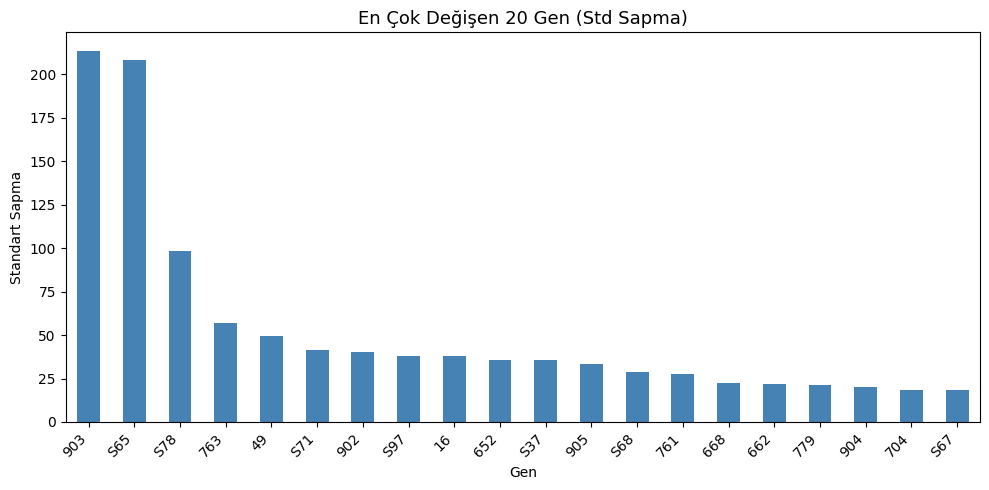

In [10]:
import matplotlib.pyplot as plt

# En az 5 örnekte değeri olan genleri filtrele
matris_filtre = matris.dropna(thresh=5)
print(f"Yeterli veri olan gen sayısı: {len(matris_filtre)}")

# Her genin standart sapmasını hesapla (değişkenlik = stres altında değişme)
std_per_gen = matris_filtre.std(axis=1).dropna().sort_values(ascending=False)

print(f"\nEn çok değişen 15 gen (std'ye göre):")
print(std_per_gen.head(15).to_string())

# Görselleştir
plt.figure(figsize=(10, 5))
std_per_gen.head(20).plot(kind="bar", color="steelblue")
plt.title("En Çok Değişen 20 Gen (Std Sapma)", fontsize=13)
plt.xlabel("Gen")
plt.ylabel("Standart Sapma")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

# Dosyayı oku - ilk 4 satır başlık/boş, gerçek veri 4. satırdan başlıyor
# usecols=range(21) ile sondaki 3 boş sütunu atla
fc = pd.read_csv(
    r"C:\Users\Sıla\Desktop\Romato\temp_additional\GSE47126_Fold_change_data.txt",
    sep="\t",
    skiprows=4,
    header=None,
    usecols=range(21),
    encoding="latin-1"
)

# Sütun isimlerini ata
fc.columns = [
    "gene_id", "accession",
    "pre_A", "pre_B", "pre_C", "pre_D", "pre_E", "pre_F",
    "post_A", "post_B", "post_C", "post_D", "post_E", "post_F",
    "avg_pre", "avg_post",
    "ratio", "log2_ratio", "f_test", "pvalue", "pvalue_adj"
]

# Boş satırları at
fc = fc.dropna(subset=["gene_id"]).reset_index(drop=True)

# Sayısal sütunları çevir ("null" string → NaN)
num_cols = ["pre_A","pre_B","pre_C","pre_D","pre_E","pre_F",
            "post_A","post_B","post_C","post_D","post_E","post_F",
            "avg_pre","avg_post","ratio","log2_ratio","f_test","pvalue","pvalue_adj"]
for col in num_cols:
    fc[col] = pd.to_numeric(fc[col], errors="coerce")

print(f"✓ {len(fc)} gen yüklendi, {len(fc.columns)} sütun")
print(f"Boş değer oranı: %{fc.isna().sum().sum() / fc.size * 100:.1f}")
fc.head(10)

✓ 243 gen yüklendi, 21 sütun
Boş değer oranı: %26.2


,gene_id,accession,pre_A,pre_B,pre_C,pre_D,pre_E,pre_F,post_A,post_B,...,post_D,post_E,post_F,avg_pre,avg_post,ratio,log2_ratio,f_test,pvalue,pvalue_adj
0,C277,K00650,2.0,0.0,3.0,1.0,1.0,2.0,6.0,0.0,...,4.0,4.0,7.0,1.50,4.67,3.11,1.64,0.062,0.032,0.021773
1,421,M31630,NaN,0.0,3.0,2.0,NaN,NaN,NaN,0.0,...,1.0,NaN,NaN,1.67,0.33,0.20,-2.32,0.250,0.267,0.230200
2,427,M34356,NaN,30.0,30.0,25.0,NaN,19.0,NaN,10.0,...,32.0,12.0,26.0,26.00,21.40,0.82,-0.28,0.331,0.400,0.428052
3,766,X60188,NaN,16.0,5.0,1.0,NaN,NaN,NaN,3.0,...,8.0,NaN,NaN,7.33,4.67,0.64,-0.65,0.243,0.623,0.606981
4,727,M84489,NaN,0.0,2.0,1.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,1.00,0.33,0.33,-1.58,0.500,0.387,0.373901
5,769,X80692,NaN,0.0,2.0,0.0,NaN,NaN,NaN,0.0,...,2.0,NaN,NaN,0.67,1.00,1.50,0.58,0.857,0.725,0.724659
6,C195,X59727,NaN,0.0,3.0,2.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,1.67,0.00,0.00,NaN,NaN,0.199,0.131778
7,C172,U25278,NaN,1.0,1.0,2.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,1.33,0.33,0.25,-2.00,1.000,0.101,0.101192
8,C207,X79483,NaN,0.0,0.0,0.0,NaN,NaN,NaN,2.0,...,0.0,NaN,NaN,0.00,0.67,NaN,NaN,NaN,0.423,0.373901
9,704,L35253; L35263,NaN,9.0,1.0,4.0,NaN,NaN,NaN,6.0,...,11.0,NaN,57.0,4.67,22.25,4.77,2.25,0.058,0.231,0.265050


In [12]:
import urllib.request
import urllib.parse
import time
import re

def accession_to_gene(accession):
    """GenBank accession → gen adı. Sırasıyla /gene=, /product=, DEFINITION dener."""
    try:
        acc = accession.split(";")[0].strip().split(" ")[0].strip()
        url = (f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
               f"?db=nucleotide&id={acc}&rettype=gb&retmode=text")
        with urllib.request.urlopen(url, timeout=10) as r:
            record = r.read().decode("utf-8")

        # 1. /gene= alanı
        m = re.search(r'/gene="([^"]+)"', record)
        if m:
            return m.group(1)

        # 2. /product= alanı
        m = re.search(r'/product="([^"]+)"', record)
        if m:
            return m.group(1)

        # 3. DEFINITION satırı (ilk anlamlı kelimeler)
        m = re.search(r'^DEFINITION\s+(.+)', record, re.MULTILINE)
        if m:
            return m.group(1).strip()[:60]

        return None
    except Exception:
        return None

# Benzersiz accession listesi
accessions = fc["accession"].dropna().unique()
print(f"Sorgulanacak accession sayısı: {len(accessions)}")

# Test (ilk 10)
print("\n--- Test (ilk 10) ---")
for acc in accessions[:10]:
    gen = accession_to_gene(acc)
    print(f"{acc:25s} → {gen}")
    time.sleep(0.4)

Sorgulanacak accession sayısı: 243

--- Test (ilk 10) ---
K00650                    → FOS
M31630                    → HB16 mRNA
M34356                    → Human active transcription factor CREB mRNA, complete cds.
X60188                    → ERK1
M84489                    → ERK2
X80692                    → ERK3
X59727                    → 63kDa protein kinase
U25278                    → ERK5
X79483                    → ERK6
L35253; L35263            → MAP kinase


In [13]:
# Test başarılıysa tüm accession'ları sorgula (~243 gen, ~2 dakika sürer)
print("Tüm genler sorgulanıyor, lütfen bekleyin...")

gen_map = {}
for i, acc in enumerate(accessions):
    gen_map[acc] = accession_to_gene(acc)
    time.sleep(0.4)
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(accessions)} tamamlandı...")

# fc tablosuna gen adı sütunu ekle
fc["gene_name"] = fc["accession"].map(gen_map)

print(f"\n✓ Tamamlandı")
print(f"Gen adı bulunan: {fc['gene_name'].notna().sum()} / {len(fc)}")
fc[["gene_id", "accession", "gene_name", "log2_ratio", "pvalue_adj"]].head(15)

Tüm genler sorgulanıyor, lütfen bekleyin...
  20/243 tamamlandı...
  40/243 tamamlandı...
  60/243 tamamlandı...
  80/243 tamamlandı...
  100/243 tamamlandı...
  120/243 tamamlandı...
  140/243 tamamlandı...
  160/243 tamamlandı...
  180/243 tamamlandı...
  200/243 tamamlandı...
  220/243 tamamlandı...
  240/243 tamamlandı...

✓ Tamamlandı
Gen adı bulunan: 243 / 243


,gene_id,accession,gene_name,log2_ratio,pvalue_adj
0,C277,K00650,FOS,1.64,0.021773
1,421,M31630,HB16 mRNA,-2.32,0.230200
2,427,M34356,"Human active transcription factor CREB mRNA, c...",-0.28,0.428052
3,766,X60188,ERK1,-0.65,0.606981
4,727,M84489,ERK2,-1.58,0.373901
5,769,X80692,ERK3,0.58,0.724659
6,C195,X59727,63kDa protein kinase,NaN,0.131778
7,C172,U25278,ERK5,-2.00,0.101192
8,C207,X79483,ERK6,NaN,0.373901
9,704,L35253; L35263,MAP kinase,2.25,0.265050


In [14]:
# İlk 20 index değerine bak
print("İlk 20 gen/prob ID:")
print(matris.index[:20].tolist())

# Kaç unique değer var
print(f"\nToplam unique ID: {matris.index.nunique()}")

# Örnek bir satıra bak
print("\nÖrnek satır (ilk gen):")
print(matris.iloc[0])

İlk 20 gen/prob ID:
['C277', '421', '427', '766', '727', '769', 'C195', 'C172', 'C207', '704', 'C179', '702', '779', '791', 'C315', '335', 'C286', '849', 'C250', 'S14']

Toplam unique ID: 243

Örnek satır (ilk gen):
GSM1145430    2.0
GSM1145431    6.0
GSM1145432    0.0
GSM1145433    0.0
GSM1145434    3.0
GSM1145435    7.0
GSM1145436    1.0
GSM1145437    4.0
GSM1145438    1.0
GSM1145439    4.0
GSM1145440    2.0
GSM1145441    7.0
GSM1148182    4.0
Name: C277, dtype: float64


## Pipeline: NASA → GEO → Klinik → Model

**Adım 1:** NASA'dan önemli gen probe ID'lerini seç (anlamlı değişenler)  
**Adım 2:** GEO matrisinden (13 astronot) o probe'ların değerlerini çek  
**Adım 3:** Klinik veriyle birleştir  
**Adım 4:** Modele ver

In [15]:
# ── ADIM 1: NASA'dan önemli probe ID'lerini seç ──────────────────────────────
# Kriter: pvalue_adj < 0.05 VEYA |log2_ratio| > 1 (en çok değişenler)

nasa_sig = fc[
    (fc["pvalue_adj"] < 0.05) | (fc["log2_ratio"].abs() > 1)
].dropna(subset=["log2_ratio"])

nasa_sig = nasa_sig.sort_values("log2_ratio", key=abs, ascending=False)
print(f"Seçilen önemli gen sayısı: {len(nasa_sig)}")
print()
print(nasa_sig[["gene_id", "gene_name", "log2_ratio", "pvalue_adj"]].to_string(index=False))

Seçilen önemli gen sayısı: 62

gene_id                                                                      gene_name  log2_ratio  pvalue_adj
    849                                                                           MKK6        3.27    0.400704
   S107 replication protein A complex 34 kd subunit\n                     homolog Rpa4       -3.17    0.377229
    S25                                                                            RPA       -2.70    0.083520
    S36                                                                           RAG1       -2.58    0.066767
   S125                                                                         CYP2F1       -2.58    0.189004
    417                                 Human Ku (p70/p80) subunit mRNA, complete cds.       -2.58    0.333140
   S124                                                                      cypj mRNA       -2.58    0.066767
    S62                                  G/T mismatch-specific thymine DNA glycos

In [16]:
# ── ADIM 2: GEO matrisinden o probe'ların değerlerini çek ─────────────────────
onemli_problar = nasa_sig["gene_id"].tolist()

# matris'ten sadece önemli probe'ları al (satırlar = genler, sütunlar = örnekler)
geo_expr = matris.loc[matris.index.isin(onemli_problar)].T  # çevir: örnek × gen
geo_expr.index.name = "sample_id"

# Sütun adlarını gene_id yerine gene_name yap
id_to_name = fc.set_index("gene_id")["gene_name"].to_dict()
geo_expr.columns = [id_to_name.get(c, c) for c in geo_expr.columns]

print(f"GEO ekspresyon tablosu: {geo_expr.shape[0]} örnek × {geo_expr.shape[1]} gen")
geo_expr

GEO ekspresyon tablosu: 13 örnek × 62 gen


,FOS,HB16 mRNA,ERK2,ERK5,MAP kinase,MKK6,nm23,TCF5,"Human p68 kinase mRNA, complete cds.",KIAA0201,...,CYP2F1,CYP21,carboxylesterase,GSTM3,Human mRNA for glutathione reductase (EC 1.6.4.2).,GST mRNA,GSTM1b,glutathione peroxidase,UGT1,Human mRNA encoding IMP:pyrophosphate phosphoribosyltransfer
sample_id,,,,,,,,,,,,,,,,,,,,,
GSM1145430,2.0,NaN,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,20.0,53.0,NaN,NaN
GSM1145431,6.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,NaN,9.0,17.0,NaN,NaN
GSM1145432,0.0,0.0,0.0,1.0,9.0,0.0,1.0,32.0,1.0,2.0,...,4.0,0.0,5.0,1.0,1.0,0.0,32.0,29.0,2.0,1.0
GSM1145433,0.0,0.0,0.0,0.0,6.0,0.0,0.0,1.0,4.0,0.0,...,0.0,2.0,1.0,1.0,0.0,2.0,10.0,23.0,2.0,0.0
GSM1145434,3.0,3.0,2.0,1.0,1.0,3.0,3.0,9.0,7.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,3.0,33.0,2.0,4.0
GSM1145435,7.0,0.0,1.0,1.0,15.0,28.0,1.0,12.0,9.0,2.0,...,1.0,0.0,1.0,0.0,0.0,2.0,2.0,17.0,0.0,1.0
GSM1145436,1.0,2.0,1.0,2.0,4.0,0.0,4.0,2.0,2.0,5.0,...,1.0,0.0,3.0,1.0,2.0,1.0,1.0,55.0,1.0,3.0
GSM1145437,4.0,1.0,0.0,0.0,11.0,1.0,1.0,5.0,11.0,0.0,...,0.0,1.0,2.0,0.0,1.0,2.0,6.0,11.0,0.0,2.0
GSM1145438,1.0,NaN,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,3.0,15.0,NaN,NaN


In [17]:
# ── ADIM 3: Klinik veri + Laboratuvar değerleri + NA Imputation ───────────────
from sklearn.impute import SimpleImputer

# df yoksa yeniden yükle
if "df" not in dir() or "disease state" not in df.columns:
    meta = {}
    with open("GSE93272_series_matrix.txt", "r") as f:
        for line in f:
            if line.startswith("!Sample_characteristics_ch1"):
                parts = line.strip().split("\t")
                first_val = parts[1].strip('"')
                if ":" in first_val:
                    key = first_val.split(":")[0].strip()
                    values = []
                    for p in parts[1:]:
                        p = p.strip('"')
                        values.append(p.split(":", 1)[1].strip() if ":" in p else None)
                    meta[key] = values
            elif line.startswith("!Sample_source_name_ch1"):
                parts = line.strip().split("\t")
                meta["source"] = [p.strip('"') for p in parts[1:]]
    df = pd.DataFrame(meta)

ra = df[df["disease state"] == "RA"].copy()

# Sayısal çevir
num_cols = ["age", "cdai", "pain.vas", "tjc66.68", "haq", "d.vas", "kowabari",
            "crp", "esr", "rf", "ccp", "ana", "mmp3"]
for col in num_cols:
    ra[col] = pd.to_numeric(ra[col], errors="coerce")

ra["gender_num"] = (ra["gender"] == "F").astype(int)
ra["hedef"] = (ra["cdai"] > 10).astype(int)

# Özellik sütunları
feature_cols = ["age", "pain.vas", "tjc66.68", "haq", "d.vas", "kowabari",
                "gender_num", "crp", "esr", "rf", "ccp", "ana", "mmp3"]

# cdai NA olan 1 satırı at (hedef değişken eksik olamaz)
ra_clean = ra[feature_cols + ["hedef"]].dropna(subset=["hedef"]).copy()

# Eksik feature değerlerini medyanla doldur
imputer = SimpleImputer(strategy="median")
ra_clean[feature_cols] = imputer.fit_transform(ra_clean[feature_cols])

klinik = ra_clean.copy()

print("NA doldurma sonrası:")
print(f"  Hasta sayısı : {len(klinik)}")
print(f"  Özellik sayısı: {len(feature_cols)}")
print(f"  Kalan NA     : {klinik.isna().sum().sum()}")
print(f"\nHedef dağılımı:")
print(klinik["hedef"].value_counts())
klinik.head()

NA doldurma sonrası:
  Hasta sayısı : 232
  Özellik sayısı: 13
  Kalan NA     : 0

Hedef dağılımı:
hedef
0    117
1    115
Name: count, dtype: int64


,age,pain.vas,tjc66.68,haq,d.vas,kowabari,gender_num,crp,esr,rf,ccp,ana,mmp3,hedef
30,60.0,80.0,23.0,1.125,66.0,120.0,1.0,0.555816,6.845490,8.965784,8.596190,5.321928,8.446256,1
31,78.0,80.0,2.0,0.875,25.0,240.0,1.0,-0.014500,5.930737,1.321928,-1.736966,7.321928,5.835419,1
32,62.0,5.0,12.0,0.625,19.0,30.0,1.0,-1.434403,6.129283,6.781360,6.059615,5.321928,6.501439,1
33,39.0,44.0,6.0,0.750,14.0,0.0,1.0,-1.888969,4.754888,8.839204,8.228819,7.321928,6.359310,0
34,27.0,90.0,20.0,1.875,77.0,0.0,1.0,-0.395929,4.000000,7.330917,8.689998,5.321928,9.224484,1


En iyi parametreler: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
CV AUROC (train): 0.980

=== TEST SONUÇLARI ===
              precision    recall  f1-score   support

           0       0.90      0.75      0.82        24
           1       0.78      0.91      0.84        23

    accuracy                           0.83        47
   macro avg       0.84      0.83      0.83        47
weighted avg       0.84      0.83      0.83        47

Test AUROC: 0.942


c:\Users\Sıla\Desktop\Romato\venv\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
1 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Sıla\Desktop\Romato\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Sıla\Desktop\Romato\venv\Lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\Sıla\Desktop\Romato\venv\Lib\site-packages\xgboost\sklearn.py", line 1512, in fit
    train_dmatrix, evals = _wrap_evaluation

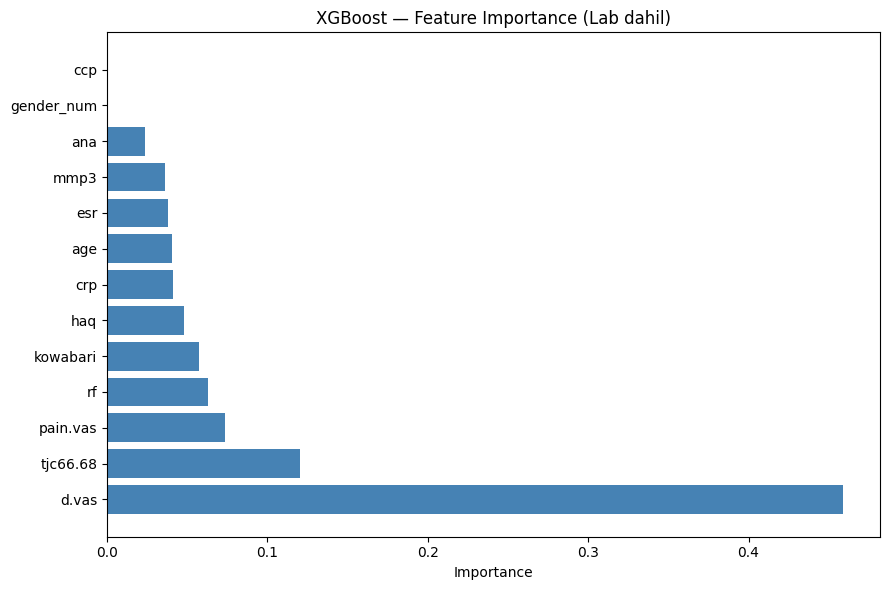

In [18]:
# ── ADIM 4: XGBoost + Hiperparametre Optimizasyonu ───────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

features = ["age", "pain.vas", "tjc66.68", "haq", "d.vas", "kowabari",
            "gender_num", "crp", "esr", "rf", "ccp", "ana", "mmp3"]
X = klinik[features]
y = klinik["hedef"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}

xgb_base = XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(xgb_base, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print(f"En iyi parametreler: {grid.best_params_}")
print(f"CV AUROC (train): {grid.best_score_:.3f}")

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\n=== TEST SONUÇLARI ===")
print(classification_report(y_test, y_pred))
print(f"Test AUROC: {roc_auc_score(y_test, y_prob):.3f}")

# Feature importance
plt.figure(figsize=(9, 6))
imp = dict(zip(features, best_model.feature_importances_))
imp_sorted = dict(sorted(imp.items(), key=lambda x: x[1], reverse=True))
plt.barh(list(imp_sorted.keys()), list(imp_sorted.values()), color="steelblue")
plt.title("XGBoost — Feature Importance (Lab dahil)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

=== d.vas OLMADAN MODEL ===
En iyi parametreler: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
CV AUROC (train): 0.964
Test AUROC      : 0.949

              precision    recall  f1-score   support

           0       0.94      0.71      0.81        24
           1       0.76      0.96      0.85        23

    accuracy                           0.83        47
   macro avg       0.85      0.83      0.83        47
weighted avg       0.85      0.83      0.83        47

=== KARŞILAŞTIRMA ===
d.vas dahil  → Test AUROC: 0.942
d.vas hariç  → Test AUROC: 0.949


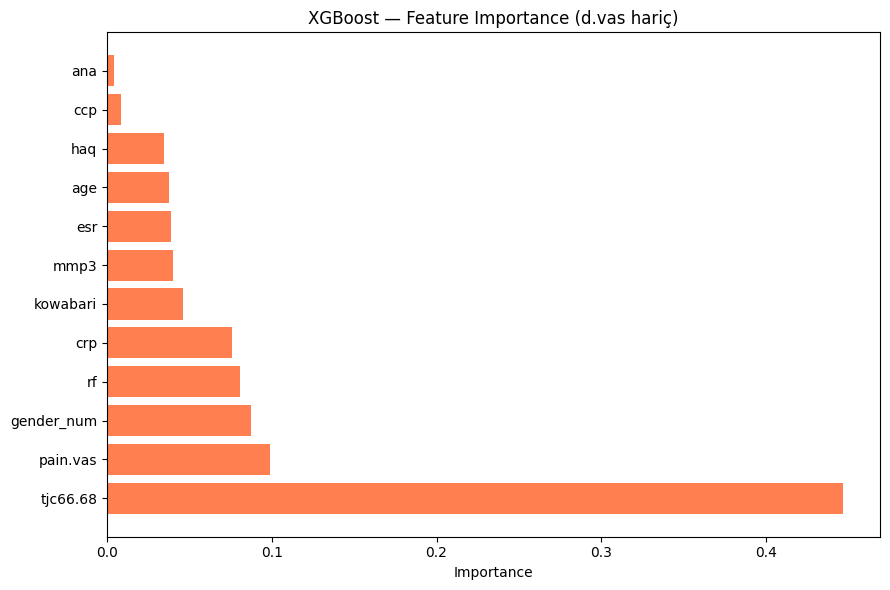

In [19]:
# ── ADIM 5: d.vas olmadan model ───────────────────────────────────────────────
features_nodvas = ["age", "pain.vas", "tjc66.68", "haq", "kowabari",
                   "gender_num", "crp", "esr", "rf", "ccp", "ana", "mmp3"]

X2 = klinik[features_nodvas]
y2 = klinik["hedef"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

grid2 = GridSearchCV(xgb_base, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid2.fit(X2_train, y2_train)

best2 = grid2.best_estimator_
y2_pred = best2.predict(X2_test)
y2_prob = best2.predict_proba(X2_test)[:, 1]

print("=== d.vas OLMADAN MODEL ===")
print(f"En iyi parametreler: {grid2.best_params_}")
print(f"CV AUROC (train): {grid2.best_score_:.3f}")
print(f"Test AUROC      : {roc_auc_score(y2_test, y2_prob):.3f}")
print()
print(classification_report(y2_test, y2_pred))

# Karşılaştırma
print("=== KARŞILAŞTIRMA ===")
print(f"d.vas dahil  → Test AUROC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"d.vas hariç  → Test AUROC: {roc_auc_score(y2_test, y2_prob):.3f}")

# Feature importance
plt.figure(figsize=(9, 6))
imp2 = dict(zip(features_nodvas, best2.feature_importances_))
imp2_sorted = dict(sorted(imp2.items(), key=lambda x: x[1], reverse=True))
plt.barh(list(imp2_sorted.keys()), list(imp2_sorted.values()), color="coral")
plt.title("XGBoost — Feature Importance (d.vas hariç)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [20]:
# ── ADIM 6: Cross-Validation ile Final Değerlendirme ─────────────────────────
from sklearn.model_selection import cross_validate
import numpy as np

# d.vas hariç en iyi model ile 5-fold CV
cv_results = cross_validate(
    best2, X2, y2,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"auroc": "roc_auc", "accuracy": "accuracy",
             "f1": "f1", "precision": "precision", "recall": "recall"},
    return_train_score=True
)

print("=== 5-FOLD CROSS VALIDATION SONUÇLARI ===")
print(f"{'Metrik':<12} {'Train':>8} {'Test':>8} {'Std':>8}")
print("-" * 40)
for m in ["auroc", "accuracy", "f1", "precision", "recall"]:
    train = cv_results[f"train_{m}"].mean()
    test  = cv_results[f"test_{m}"].mean()
    std   = cv_results[f"test_{m}"].std()
    print(f"{m:<12} {train:>8.3f} {test:>8.3f} {std:>8.3f}")

print(f"\nHer fold AUROC: {[round(x,3) for x in cv_results['test_auroc']]}")
print(f"Ortalama      : {cv_results['test_auroc'].mean():.3f} ± {cv_results['test_auroc'].std():.3f}")

=== 5-FOLD CROSS VALIDATION SONUÇLARI ===
Metrik          Train     Test      Std
----------------------------------------
auroc           1.000    0.944    0.023
accuracy        1.000    0.849    0.040
f1              1.000    0.841    0.051
precision       1.000    0.882    0.069
recall          1.000    0.817    0.111

Her fold AUROC: [0.953, 0.908, 0.957, 0.93, 0.974]
Ortalama      : 0.944 ± 0.023


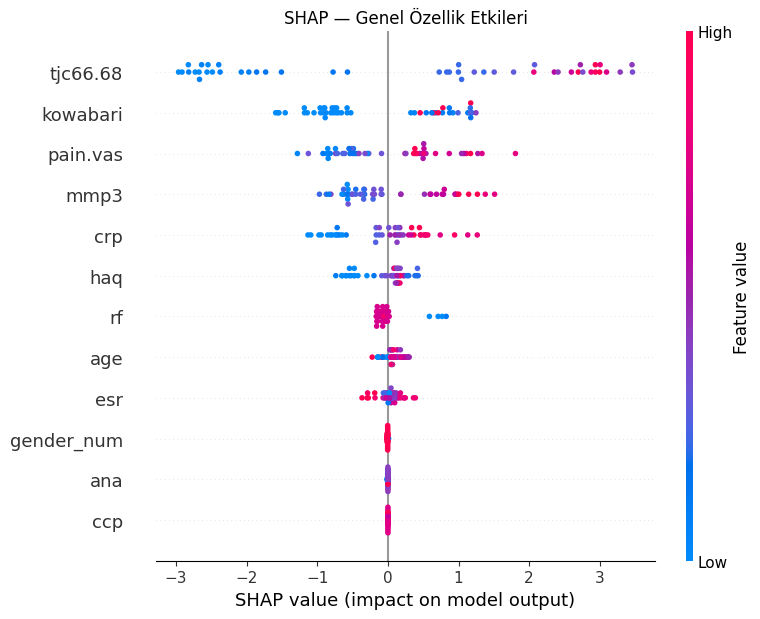

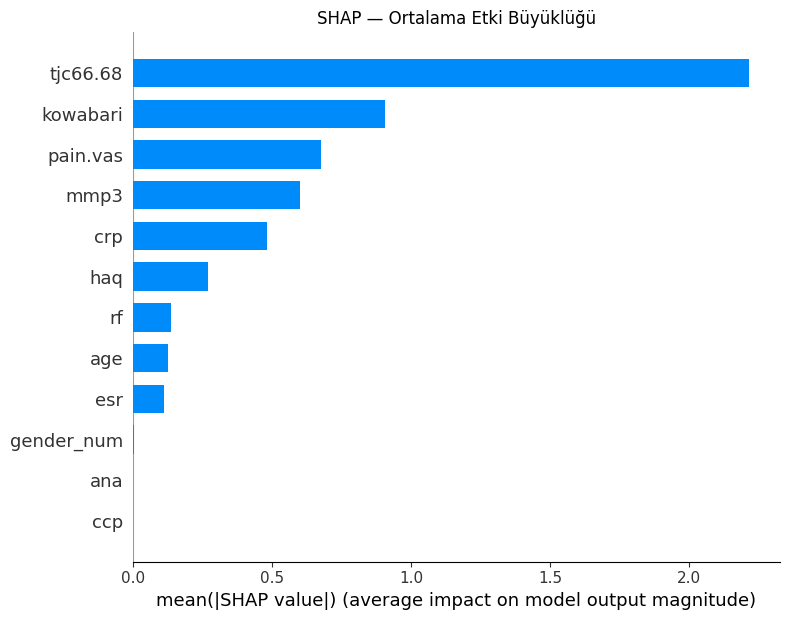

En yüksek yanıtsızlık riski: Hasta #38 (risk: %99.7)


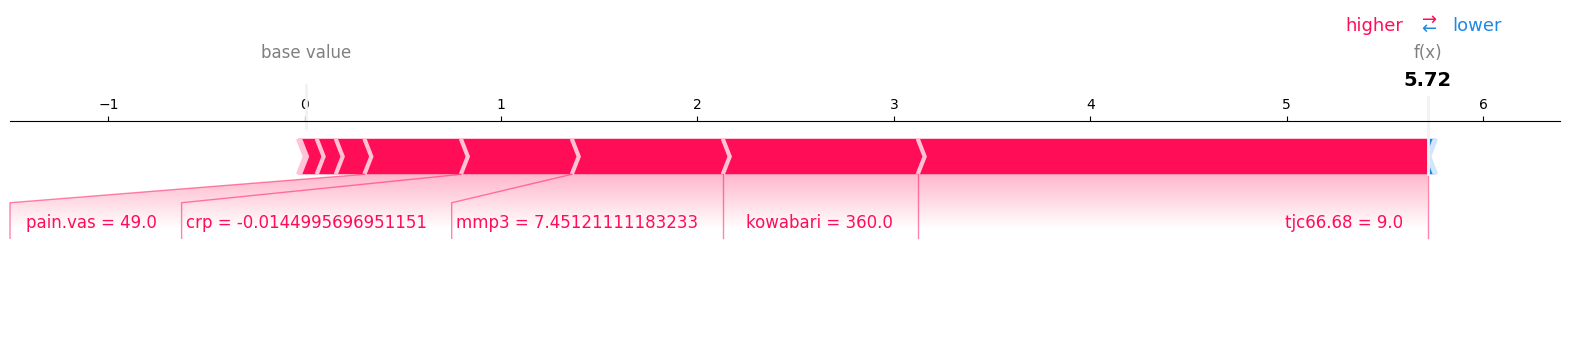

<Figure size 640x480 with 0 Axes>

In [21]:
# ── ADIM 7: SHAP Analizi ──────────────────────────────────────────────────────
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best2)
shap_values = explainer.shap_values(X2_test)

# 1. Summary plot — tüm özellikler genel etki
plt.figure()
shap.summary_plot(shap_values, X2_test, feature_names=features_nodvas, show=False)
plt.title("SHAP — Genel Özellik Etkileri")
plt.tight_layout()
plt.show()

# 2. Bar plot — ortalama mutlak etki
plt.figure()
shap.summary_plot(shap_values, X2_test, feature_names=features_nodvas,
                  plot_type="bar", show=False)
plt.title("SHAP — Ortalama Etki Büyüklüğü")
plt.tight_layout()
plt.show()

# 3. Tek hasta açıklaması — en yüksek riskli hasta
en_riskli = int(y2_prob.argmax())
print(f"En yüksek yanıtsızlık riski: Hasta #{en_riskli} (risk: %{y2_prob[en_riskli]*100:.1f})")
shap.force_plot(
    explainer.expected_value,
    shap_values[en_riskli],
    X2_test.iloc[en_riskli],
    feature_names=features_nodvas,
    matplotlib=True
)
plt.tight_layout()
plt.show()

In [22]:
# GSE93272 dosyasında gen ifadesi satırları var mı?
with open("GSE93272_series_matrix.txt", "r") as f:
    for i, line in enumerate(f):
        if i > 200:  # İlk 200 satıra bak
            break
        if not line.startswith("!") and not line.startswith("^") and not line.startswith("#"):
            print(line[:100])



"ID_REF"	"GSM2449608"	"GSM2449609"	"GSM2449610"	"GSM2449611"	"GSM2449612"	"GSM2449613"	"GSM2449614"	
"1007_s_at"	7.61240809	7.567729221	7.270872468	7.409437072	7.573101355	7.310653407	7.605666644	7.370
"1053_at"	6.414243327	6.244398734	6.452395693	6.522964073	6.651882271	6.616908617	6.219087406	6.3543
"117_at"	9.191961057	9.110493288	9.534272384	10.08262825	9.62087369	9.684034463	9.129527991	9.539999
"121_at"	8.047867529	7.955304709	7.844322316	8.113362312	7.890704675	7.946275136	7.845397751	7.97959
"1255_g_at"	3.517207672	3.402866178	3.419306201	3.364096957	3.407845458	3.201833822	3.574707142	3.58
"1294_at"	8.198454173	8.413477076	8.255388248	8.497142338	8.48674672	8.387812259	8.310192415	8.39649
"1316_at"	6.940117881	7.366438139	7.32204407	7.468686458	6.995876542	6.823267524	6.84096872	7.208336
"1320_at"	3.98260053	4.103122985	3.713520702	4.092684235	3.729074243	3.777083913	4.05641299	3.731359
"1405_i_at"	11.90353983	11.80276211	12.00382229	12.11576381	11.53139399	11.43624749	11.69

# Cinsiyet Analizi

## 1. Korelasyon Analizi — gender_num ile Diğer Değişkenler

gender_num özelliği model feature importance'ta neredeyse sıfır çıktı. İki olası açıklama:
- Veri dengesizliği (çoğunluk kadın olabilir)
- Cinsiyet etkisi tjc66.68, kowabari gibi değişkenler üzerinden dolaylı öğrenilmiş olabilir (multikolineerite)

=== CİNSİYET DAĞILIMI (RA Hastaları) ===
Kadın (F=1): 205  (88.4%)
Erkek (M=0): 27  (11.6%)

=== HEDEF DEĞİŞKENE GÖRE CİNSİYET ===
        Yanıt Var (0)  Yanıtsız (1)  Toplam
Erkek               9            18      27
Kadın             108            97     205
Toplam            117           115     232

=== GENDER_NUM KORELASYONLARI (Point-Biserial / Spearman) ===
 feature  spearman_r  p_value significant
     crp   -0.239253 0.000235           ✓
    mmp3   -0.187858 0.004085           ✓
     ana    0.173504 0.008083           ✓
     ccp    0.138147 0.035472           ✓
   hedef   -0.124105 0.059106            
kowabari   -0.101861 0.121828            
     age    0.087572 0.183781            
     haq    0.073743 0.263276            
pain.vas   -0.060422 0.359566            
      rf    0.043675 0.507997            
     esr    0.021080 0.749433            
tjc66.68   -0.014501 0.826116            


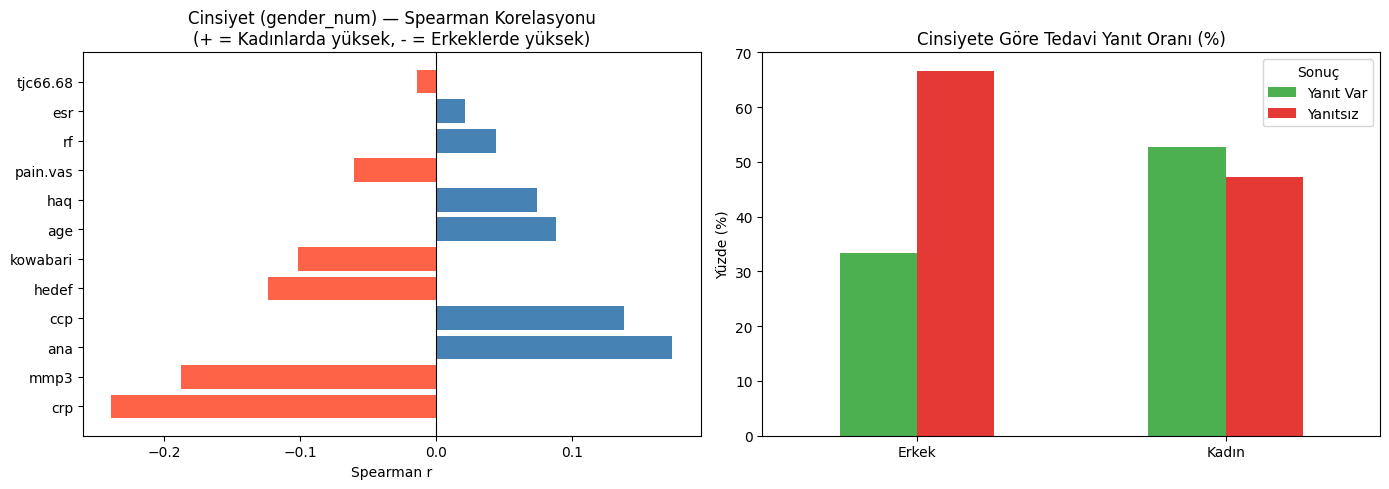

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ── 1. Cinsiyet dağılımı ─────────────────────────────────────────────────────
print("=== CİNSİYET DAĞILIMI (RA Hastaları) ===")
gender_counts = klinik["gender_num"].value_counts()
print(f"Kadın (F=1): {gender_counts.get(1, 0)}  ({gender_counts.get(1, 0)/len(klinik)*100:.1f}%)")
print(f"Erkek (M=0): {gender_counts.get(0, 0)}  ({gender_counts.get(0, 0)/len(klinik)*100:.1f}%)")

print("\n=== HEDEF DEĞİŞKENE GÖRE CİNSİYET ===")
ct = pd.crosstab(klinik["gender_num"], klinik["hedef"], margins=True)
ct.index = ["Erkek", "Kadın", "Toplam"]
ct.columns = ["Yanıt Var (0)", "Yanıtsız (1)", "Toplam"]
print(ct)

# ── 2. gender_num ile diğer değişkenler arası korelasyon ─────────────────────
print("\n=== GENDER_NUM KORELASYONLARI (Point-Biserial / Spearman) ===")
features_for_corr = ["age", "pain.vas", "tjc66.68", "haq", "kowabari",
                     "crp", "esr", "rf", "ccp", "ana", "mmp3", "hedef"]

corr_results = []
for feat in features_for_corr:
    col = pd.to_numeric(klinik[feat], errors="coerce")
    mask = col.notna() & klinik["gender_num"].notna()
    if mask.sum() < 10:
        continue
    r, p = stats.spearmanr(klinik.loc[mask, "gender_num"], col[mask])
    corr_results.append({"feature": feat, "spearman_r": r, "p_value": p,
                          "significant": "✓" if p < 0.05 else ""})

corr_df = pd.DataFrame(corr_results).sort_values("spearman_r", key=abs, ascending=False)
print(corr_df.to_string(index=False))

# ── 3. Görselleştirme ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Korelasyon barplot
colors = ["tomato" if r < 0 else "steelblue" for r in corr_df["spearman_r"]]
axes[0].barh(corr_df["feature"], corr_df["spearman_r"], color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Cinsiyet (gender_num) — Spearman Korelasyonu\n(+ = Kadınlarda yüksek, - = Erkeklerde yüksek)")
axes[0].set_xlabel("Spearman r")

# Hedef bazında cinsiyet dağılımı
klinik_plot = klinik.copy()
klinik_plot["Cinsiyet"] = klinik_plot["gender_num"].map({1: "Kadın", 0: "Erkek"})
klinik_plot["Sonuç"] = klinik_plot["hedef"].map({0: "Yanıt Var", 1: "Yanıtsız"})
ct_pct = klinik_plot.groupby(["Cinsiyet", "Sonuç"]).size().unstack(fill_value=0)
ct_pct_norm = ct_pct.div(ct_pct.sum(axis=1), axis=0) * 100
ct_pct_norm.plot(kind="bar", ax=axes[1], color=["#4CAF50", "#E53935"], rot=0)
axes[1].set_title("Cinsiyete Göre Tedavi Yanıt Oranı (%)")
axes[1].set_ylabel("Yüzde (%)")
axes[1].set_xlabel("")
axes[1].legend(title="Sonuç")

plt.tight_layout()
plt.show()

## 2. Cinsiyet Bazlı Stratifiye Model — AUROC Karşılaştırması

Kadın ve erkek hastalar için ayrı XGBoost modelleri kurarak performansları karşılaştırıyoruz.


  Kadın (F): 205 hasta | Yanıt Var: 108 | Yanıtsız: 97
  AUROC (5-fold): 0.947 ± 0.030
  Her fold: [0.914, 0.91, 0.986, 0.962, 0.962]
  F1 (ort): 0.905
  Accuracy (ort): 0.907

  Erkek (M): 27 hasta | Yanıt Var: 9 | Yanıtsız: 18
  AUROC (5-fold): 0.925 ± 0.150
  Her fold: [0.625, 1.0, 1.0, 1.0, 1.0]
  F1 (ort): 0.843
  Accuracy (ort): 0.813


C:\Users\Sıla\AppData\Local\Temp\ipykernel_13060\1896299630.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(valid_results.values(), labels=valid_results.keys(), patch_artist=True,


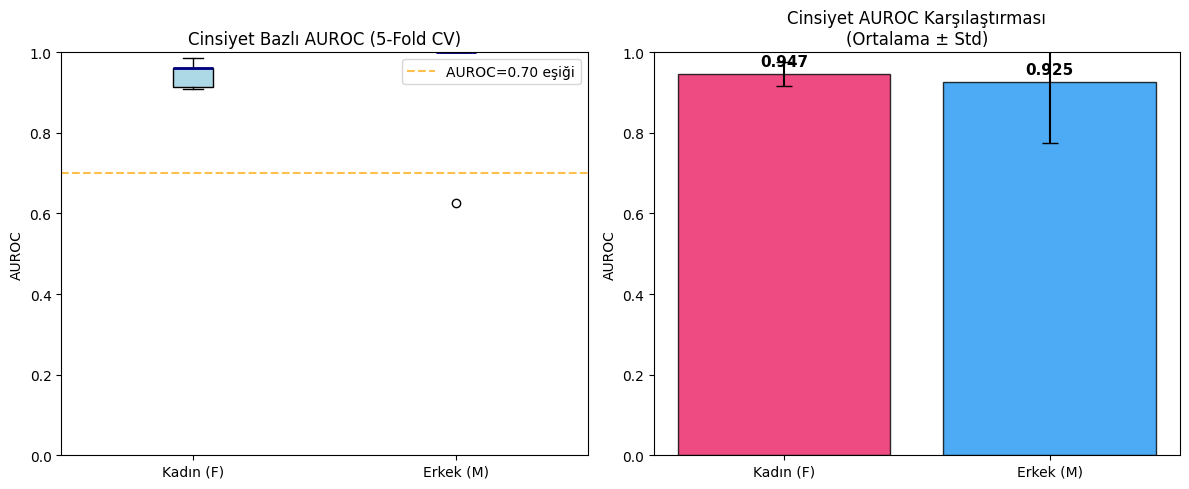


  REFERANS — Tüm hastalar (cinsiyet özelliği hariç)
  AUROC: 0.945 ± 0.023


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt

# gender_num hariç özellikler (cinsiyet grubuna göre ayrılınca zaten sabit olur)
features_nogender = ["age", "pain.vas", "tjc66.68", "haq", "kowabari",
                     "crp", "esr", "rf", "ccp", "ana", "mmp3"]

klinik_clean = klinik.copy()
for f in features_nogender + ["hedef", "gender_num"]:
    klinik_clean[f] = pd.to_numeric(klinik_clean[f], errors="coerce")

# XGBoost parametreleri (best2 ile aynı)
xgb_params = best2.get_params()
xgb_params.pop("callbacks", None)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for gender_val, label in [(1, "Kadın (F)"), (0, "Erkek (M)")]:
    subset = klinik_clean[klinik_clean["gender_num"] == gender_val].copy()
    X_sub = subset[features_nogender]
    y_sub = subset["hedef"]

    # Eksik veri imputation
    imp = SimpleImputer(strategy="median")
    X_sub_imp = imp.fit_transform(X_sub)

    n_pos = y_sub.sum()
    n_neg = (y_sub == 0).sum()
    print(f"\n{'='*50}")
    print(f"  {label}: {len(subset)} hasta | Yanıt Var: {n_neg} | Yanıtsız: {n_pos}")
    print(f"{'='*50}")

    if n_pos < 5 or n_neg < 5:
        print("  UYARI: Yetersiz örnek sayısı, bu grup atlanıyor.")
        results[label] = None
        continue

    model = XGBClassifier(**xgb_params)
    cv_res = cross_validate(
        model, X_sub_imp, y_sub,
        cv=cv_strat,
        scoring={"auroc": "roc_auc", "f1": "f1", "accuracy": "accuracy"},
        return_train_score=False
    )

    auroc_scores = cv_res["test_auroc"]
    results[label] = auroc_scores
    print(f"  AUROC (5-fold): {auroc_scores.mean():.3f} ± {auroc_scores.std():.3f}")
    print(f"  Her fold: {[round(x, 3) for x in auroc_scores]}")
    print(f"  F1 (ort): {cv_res['test_f1'].mean():.3f}")
    print(f"  Accuracy (ort): {cv_res['test_accuracy'].mean():.3f}")

# ── Karşılaştırma grafiği ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
valid_results = {k: v for k, v in results.items() if v is not None}
axes[0].boxplot(valid_results.values(), labels=valid_results.keys(), patch_artist=True,
                boxprops=dict(facecolor="lightblue"), medianprops=dict(color="navy", linewidth=2))
axes[0].set_title("Cinsiyet Bazlı AUROC (5-Fold CV)")
axes[0].set_ylabel("AUROC")
axes[0].set_ylim(0, 1)
axes[0].axhline(0.7, color="orange", linestyle="--", alpha=0.7, label="AUROC=0.70 eşiği")
axes[0].legend()

# Bar plot with error bars
labels_bar = list(valid_results.keys())
means = [v.mean() for v in valid_results.values()]
stds  = [v.std()  for v in valid_results.values()]
colors_bar = ["#E91E63", "#2196F3"][:len(labels_bar)]
bars = axes[1].bar(labels_bar, means, yerr=stds, capsize=6,
                   color=colors_bar, alpha=0.8, edgecolor="black")
axes[1].set_title("Cinsiyet AUROC Karşılaştırması\n(Ortalama ± Std)")
axes[1].set_ylabel("AUROC")
axes[1].set_ylim(0, 1)
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, mean + 0.02,
                 f"{mean:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# ── Genel model AUROC referansı ───────────────────────────────────────────────
from sklearn.model_selection import cross_validate
ref_cv = cross_validate(
    XGBClassifier(**xgb_params),
    SimpleImputer(strategy="median").fit_transform(klinik_clean[features_nogender]),
    klinik_clean["hedef"],
    cv=cv_strat,
    scoring={"auroc": "roc_auc"}
)
print(f"\n{'='*50}")
print(f"  REFERANS — Tüm hastalar (cinsiyet özelliği hariç)")
print(f"  AUROC: {ref_cv['test_auroc'].mean():.3f} ± {ref_cv['test_auroc'].std():.3f}")
print(f"{'='*50}")

In [25]:
# Klinik verideki hasta sayısı
print(f"Klinik veri hasta sayısı: {len(ra)}")
print(f"Klinik veri ID örneği: {ra.index[:3].tolist()}")

# Gen ifadesi matriksini oku
geo_expr = pd.read_csv("GSE93272_series_matrix.txt", 
                        sep="\t", comment="!", index_col=0)

print(f"\nGen ifadesi örnek sayısı: {geo_expr.shape[1]}")
print(f"Gen ifadesi ID örneği: {geo_expr.columns[:3].tolist()}")

Klinik veri hasta sayısı: 232
Klinik veri ID örneği: [30, 31, 32]

Gen ifadesi örnek sayısı: 275
Gen ifadesi ID örneği: ['GSM2449608', 'GSM2449609', 'GSM2449610']


In [26]:
with open("GSE93272_series_matrix.txt", "r") as f:
    for line in f:
        if line.startswith("!Sample_title") or line.startswith("!Sample_description"):
            print(line[:300])
            break

!Sample_title	"Whole blood from healthy control(HC003_1)"	"Whole blood from healthy control(HC004_1)"	"Whole blood from healthy control(HC005_1)"	"Whole blood from healthy control(HC006_1)"	"Whole blood from healthy control(HC007_1)"	"Whole blood from healthy control(HC008_1)"	"Whole blood from heal


In [27]:
with open("GSE93272_series_matrix.txt", "r") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            parts = line.strip().split("\t")
            # RA olanları bul
            for p in parts:
                if "RA" in p or "R0" in p:
                    print(p)
                    break

In [28]:
with open("GSE93272_series_matrix.txt", "r") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            parts = line.strip().split("\t")
            print(f"Toplam sample: {len(parts)-1}")
            print(f"İlk 5: {parts[1:6]}")
            print(f"Son 5: {parts[-5:]}")
            break

Toplam sample: 275
İlk 5: ['"Whole blood from healthy control(HC003_1)"', '"Whole blood from healthy control(HC004_1)"', '"Whole blood from healthy control(HC005_1)"', '"Whole blood from healthy control(HC006_1)"', '"Whole blood from healthy control(HC007_1)"']
Son 5: ['"Whole blood from rheumatoid arthritis(K9867_2)"', '"Whole blood from rheumatoid arthritis(K9919_2)"', '"Whole blood from rheumatoid arthritis(K9967_2)"', '"Whole blood from rheumatoid arthritis(K9968_2)"', '"Whole blood from rheumatoid arthritis(K9969_2)"']


In [29]:
# Klinik verinin tüm sütunlarına bak
print(ra.columns.tolist())
print("\nİlk 3 satır:")
print(ra.head(3))

['source', 'individual id', 'disease state', 'tissue', 'batch', 'rin', 'age', 'gender', 'cdai', 'kowabari', 'haq', 'd.vas', 'pain.vas', 'symptom.vas', 'tjc66.68', 'sjc66.68', 'crp.das28', 'esr.das28', 'crp', 'esr', 'mmp3', 'hras38', 'acr', 'sdai', 'tjc28', 'sjc28', 'tjc38', 'sjs38', 'rf', 'ccp', 'ana', 'ifx_days', 'ifx.ir_days', 'mtx_days', 'mtx.ir_days', 'tcz_days', 'tcz.ir_days', 'gender_num', 'hedef']

İlk 3 satır:
                                   source individual id disease state  \
30  Whole blood from rheumatoid arthritis          R060            RA   
31  Whole blood from rheumatoid arthritis          R022            RA   
32  Whole blood from rheumatoid arthritis          R003            RA   

         tissue batch  rin  age gender  cdai  kowabari  ...       ccp  \
30  whole blood     1  8.2   60      F  37.8       120  ...  8.596190   
31  whole blood     1  8.5   78      F  13.3       240  ... -1.736966   
32  whole blood     1  8.4   62      F  13.4        30  ...  6.059

In [30]:
with open("GSE93272_series_matrix.txt", "r") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")
            # K9867 gibi ID var mı?
            for p in parts[:5]:
                print(p)
            break

!Sample_characteristics_ch1
"individual id: HC003"
"individual id: HC004"
"individual id: HC005"
"individual id: HC006"


In [31]:
with open("GSE93272_series_matrix.txt", "r") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")
            first_val = parts[1].strip('"')
            if "individual id" in first_val.lower():
                ids = [p.strip('"').split(":")[-1].strip() for p in parts[1:]]
                print(f"Toplam ID: {len(ids)}")
                print(f"İlk 10: {ids[:10]}")
                print(f"Son 10: {ids[-10:]}")
                break

Toplam ID: 275
İlk 10: ['HC003', 'HC004', 'HC005', 'HC006', 'HC007', 'HC008', 'HC009', 'HC010', 'HC011', 'HC012']
Son 10: ['R110', 'R085', 'R076', 'R056', 'R104', 'R041', 'R049', 'R029', 'R085', 'R054']


In [32]:
# Tüm sample ID'lerini ve GSM ID'lerini eşleştir
gsm_ids = []
individual_ids = []

with open("GSE93272_series_matrix.txt", "r") as f:
    for line in f:
        if line.startswith("!Sample_geo_accession"):
            parts = line.strip().split("\t")
            gsm_ids = [p.strip('"') for p in parts[1:]]
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")
            first_val = parts[1].strip('"')
            if "individual id" in first_val.lower():
                individual_ids = [p.strip('"').split(":")[-1].strip() for p in parts[1:]]

# Eşleştirme tablosu
eslesme = pd.DataFrame({
    "gsm_id": gsm_ids,
    "individual_id": individual_ids
})

print(f"Toplam eşleşme: {len(eslesme)}")
print(eslesme.tail(20))

# Klinik verideki ID'lerle kaç tane örtüşüyor?
klinik_ids = ra.index.astype(str).tolist()
ortak = eslesme[eslesme["individual_id"].isin(klinik_ids)]
print(f"\nOrtak hasta sayısı: {len(ortak)}")

Toplam eşleşme: 275
         gsm_id individual_id
255  GSM2449868          R019
256  GSM2449869          R071
257  GSM2449870          R071
258  GSM2449871          R108
259  GSM2449872          R043
260  GSM2449873          R097
261  GSM2449874          R074
262  GSM2449875          R098
263  GSM2449876          R059
264  GSM2449877          R047
265  GSM2449878          R110
266  GSM2449879          R085
267  GSM2449880          R076
268  GSM2449881          R056
269  GSM2449882          R104
270  GSM2449883          R041
271  GSM2449884          R049
272  GSM2449885          R029
273  GSM2449886          R085
274  GSM2449887          R054

Ortak hasta sayısı: 0


In [33]:
# Klinik veride hangi sütunlar var
print(ra.columns.tolist())
print("\nİlk 3 satır tam:")
print(ra.head(3).to_string())

['source', 'individual id', 'disease state', 'tissue', 'batch', 'rin', 'age', 'gender', 'cdai', 'kowabari', 'haq', 'd.vas', 'pain.vas', 'symptom.vas', 'tjc66.68', 'sjc66.68', 'crp.das28', 'esr.das28', 'crp', 'esr', 'mmp3', 'hras38', 'acr', 'sdai', 'tjc28', 'sjc28', 'tjc38', 'sjs38', 'rf', 'ccp', 'ana', 'ifx_days', 'ifx.ir_days', 'mtx_days', 'mtx.ir_days', 'tcz_days', 'tcz.ir_days', 'gender_num', 'hedef']

İlk 3 satır tam:
                                   source individual id disease state       tissue batch  rin  age gender  cdai  kowabari    haq  d.vas  pain.vas symptom.vas  tjc66.68 sjc66.68 crp.das28 esr.das28       crp       esr      mmp3  hras38 acr   sdai tjc28 sjc28 tjc38 sjs38        rf       ccp       ana ifx_days ifx.ir_days mtx_days mtx.ir_days tcz_days tcz.ir_days  gender_num  hedef
30  Whole blood from rheumatoid arthritis          R060            RA  whole blood     1  8.2   60      F  37.8       120  1.125     66      80.0          82        23       24      5.93      

In [34]:
# Klinik verideki individual id sütununu kullan
klinik_ids = ra["individual id"].tolist()

ortak = eslesme[eslesme["individual_id"].isin(klinik_ids)]
print(f"Ortak hasta sayısı: {len(ortak)}")
print(ortak.head(10))

Ortak hasta sayısı: 232
        gsm_id individual_id
30  GSM2449638          R060
31  GSM2449639          R022
32  GSM2449640          R003
33  GSM2449641          R008
34  GSM2449642          R028
35  GSM2449643          R002
36  GSM2449644          R046
37  GSM2449645          R029
38  GSM2449646          R034
39  GSM2449647          R004


In [35]:
# Gen ifadesi matriksini oku
geo_expr = pd.read_csv("GSE93272_series_matrix.txt", 
                        sep="\t", comment="!", index_col=0)

print(f"Gen ifadesi boyutu: {geo_expr.shape}")
print(f"İlk 3 sütun: {geo_expr.columns[:3].tolist()}")

Gen ifadesi boyutu: (54613, 275)
İlk 3 sütun: ['GSM2449608', 'GSM2449609', 'GSM2449610']


In [36]:
with open("GSE93272_series_matrix.txt", "r") as f:
    for line in f:
        if line.startswith("!Series_platform_id"):
            print(line.strip())
            break

!Series_platform_id	"GPL570"


prob

Geo daki prob_idler ve gen isimleri var ve bizim prob idlerdeki gen isimlerini bulmamız gerek o yüzden bu eşleştirme dosyasını indiriyorum

In [37]:
import pandas as pd

annot = pd.read_csv(r"C:\Users\Sıla\Desktop\Romato\GPL570-55999.txt", sep="\t", index_col=0, 
                    comment="#", low_memory=False, skiprows=0)

print(f"Boyut: {annot.shape}")
print(f"Sütunlar: {annot.columns.tolist()[:10]}")
print(annot.head(3))

Boyut: (54675, 15)
Sütunlar: ['GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol']
           GB_ACC SPOT_ID Species Scientific Name Annotation Date  \
ID                                                                  
1007_s_at  U48705     NaN            Homo sapiens     Oct 6, 2014   
1053_at    M87338     NaN            Homo sapiens     Oct 6, 2014   
117_at     X51757     NaN            Homo sapiens     Oct 6, 2014   

               Sequence Type                  Sequence Source  \
ID                                                              
1007_s_at  Exemplar sequence  Affymetrix Proprietary Database   
1053_at    Exemplar sequence                          GenBank   
117_at     Exemplar sequence  Affymetrix Proprietary Database   

                                          Target Description  \
ID                                                  

Gen sembolü sütununu arıyorum

In [38]:
# Tüm sütunları gör
print(annot.columns.tolist())

['GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']


gen_Symbol var aradığımız mı bakalım katakülliye gelmeyelim

In [39]:
# Gene Symbol sütununa bak
print(annot["Gene Symbol"].head(20).tolist())

['DDR1 /// MIR4640', 'RFC2', 'HSPA6', 'PAX8', 'GUCA1A', 'MIR5193 /// UBA7', 'THRA', 'PTPN21', 'CCL5', 'CYP2E1', 'EPHB3', 'ESRRA', 'CYP2A6', 'SCARB1', 'TTLL12', 'LINC00152 /// LOC101930489', 'WFDC2', 'MAPK1', 'MAPK1', 'ADAM32']


bakalım nasadan çektiğimiz genlerle aynı mı

In [40]:
# NASA gen listesini göster
print("NASA genleri:")
print(nasa_sig["gene_name"].tolist())

NASA genleri:
['MKK6', 'replication protein A complex 34 kd subunit\n                     homolog Rpa4', 'RPA', 'RAG1', 'CYP2F1', 'Human Ku (p70/p80) subunit mRNA, complete cds.', 'cypj mRNA', 'G/T mismatch-specific thymine DNA glycosylase', 'Human chaperonin (HSP60) mRNA, complete cds.', 'RAG2', 'CYP1A1', 'TOP1', 'DDB2', 'BRCA2', 'HB16 mRNA', 'MAP kinase', 'MSH6', 'Human mRNA for glutathione reductase (EC 1.6.4.2).', 'KIAA0201', 'nm23', 'BTF2p44', 'TCP1', 'mda-6', 'CYP2D', 'ERK5', 'RAD54', 'flavin-containing monooxygenase 4', 'HAAG', 'excision repair protein', 'LIG4', 'immunophilin', 'FKBP13', 'Human p68 kinase mRNA, complete cds.', 'FOS', 'ercc2 gene product', 'ERp72', 'GSTM3', 'hsp70', 'GST mRNA', 'ERK2', 'protein disulfide isomerase-related protein\n                     (PDIR)', 'BAG1', 'Human mRNA encoding IMP:pyrophosphate phosphoribosyltransfer', 'ATM', 'HHR23A', 'topIIb', 'UGT1', 'Human mRNA for uracil-DNA glycosylase.', '90kDa heat shock protein mRNA', 'heat shock protein HSP7

Çok kötü yapmışlar abi nasada o kadar para alıyolar bir de temizleyelim temiz genleri alıcaz

In [41]:
# Temiz gen sembolleri — kısa ve büyük harf olanlar
temiz_genler = []
for g in nasa_sig["gene_name"].tolist():
    g = g.strip()
    # Kısa (max 10 karakter), boşluk içermeyenler büyük ihtimalle sembol
    if len(g) <= 10 and "\n" not in g and "Human" not in g and "mRNA" not in g:
        temiz_genler.append(g)

print(f"Temiz gen sayısı: {len(temiz_genler)}")
print(temiz_genler)

Temiz gen sayısı: 39
['MKK6', 'RPA', 'RAG1', 'CYP2F1', 'RAG2', 'CYP1A1', 'TOP1', 'DDB2', 'BRCA2', 'MAP kinase', 'MSH6', 'KIAA0201', 'nm23', 'BTF2p44', 'TCP1', 'mda-6', 'CYP2D', 'ERK5', 'RAD54', 'HAAG', 'LIG4', 'FKBP13', 'FOS', 'ERp72', 'GSTM3', 'hsp70', 'ERK2', 'BAG1', 'ATM', 'HHR23A', 'topIIb', 'UGT1', 'CYP21', 'XRCC1', 'ERCC1', 'TCF5', 'FKBP54', 'MRP', 'GSTM1b']


bulduk,bakalım bizim geoda var mı bunlar

In [42]:
import pandas as pd

# Tam yolu kullan
annot = pd.read_csv(r"C:\Users\Sıla\Desktop\Romato\GPL570-55999.txt", 
                    sep="\t", index_col=0, comment="#", low_memory=False)

prob_gen = annot[["Gene Symbol"]].copy()
prob_gen.columns = ["gene_symbol"]
prob_gen = prob_gen[prob_gen["gene_symbol"].notna()]
prob_gen = prob_gen[prob_gen["gene_symbol"] != ""]

print(f"Toplam prob: {len(prob_gen)}")
print(prob_gen.head(3))

Toplam prob: 45782
                gene_symbol
ID                         
1007_s_at  DDR1 /// MIR4640
1053_at                RFC2
117_at                HSPA6


In [43]:
temiz_genler = ['MKK6', 'RPA', 'RAG1', 'CYP2F1', 'RAG2', 'CYP1A1', 'TOP1', 'DDB2', 
                'BRCA2', 'MAP kinase', 'MSH6', 'KIAA0201', 'nm23', 'BTF2p44', 'TCP1', 
                'mda-6', 'CYP2D', 'ERK5', 'RAD54', 'HAAG', 'LIG4', 'FKBP13', 'FOS', 
                'ERp72', 'GSTM3', 'hsp70', 'ERK2', 'BAG1', 'ATM', 'HHR23A', 'topIIb', 
                'UGT1', 'CYP21', 'XRCC1', 'ERCC1', 'TCF5', 'FKBP54', 'MRP', 'GSTM1b']

temiz_genler_upper = [g.strip().upper() for g in temiz_genler]

bulunan_probs = []

for prob_id, row in prob_gen.iterrows():
    semboller = str(row["gene_symbol"]).upper().split("///")
    semboller = [s.strip() for s in semboller]
    for s in semboller:
        if s in temiz_genler_upper:
            bulunan_probs.append({
                "prob_id": prob_id,
                "gene_symbol": s
            })

geo_nasa_probs = pd.DataFrame(bulunan_probs)
print(f"GEO'da bulunan NASA geni sayısı: {geo_nasa_probs['gene_symbol'].nunique()}")
print(geo_nasa_probs)

GEO'da bulunan NASA geni sayısı: 16
         prob_id gene_symbol
0     1553387_at         ATM
1     1554631_at         ATM
2     1554994_at        RAG1
3   1569034_a_at        MSH6
4     1570352_at         ATM
5      202387_at        BAG1
6    202554_s_at       GSTM3
7      202911_at        MSH6
8      203409_at        DDB2
9      203655_at       XRCC1
10     203719_at       ERCC1
11   203720_s_at       ERCC1
12     205749_at      CYP1A1
13     206235_at        LIG4
14     206591_at        RAG1
15     207913_at      CYP2F1
16   208368_s_at       BRCA2
17   208442_s_at         ATM
18   208778_s_at        TCP1
19   208900_s_at        TOP1
20   208901_s_at        TOP1
21     209189_at         FOS
22   210858_x_at         ATM
23     211449_at        MSH6
24   211450_s_at        MSH6
25   211475_s_at        BAG1
26     212672_at         ATM
27     214727_at       BRCA2
28     215117_at        RAG2
29     222010_at        TCP1
30   222011_s_at        TCP1
31     227766_at        LIG4
32     

In [44]:
# Önce geo_ra değişkenini tekrar oluştur
# Gen ifadesi matriksini oku
geo_expr = pd.read_csv(r"C:\Users\Sıla\Desktop\Romato\venv\GSE93272_series_matrix.txt",
                        sep="\t", comment="!", index_col=0)

# Sadece RA hastalarını al
ra_gsm_ids = eslesme["gsm_id"].tolist()
geo_ra = geo_expr[ra_gsm_ids]

# Sütun isimlerini GSM → hasta ID'ye çevir
gsm_to_id = dict(zip(eslesme["gsm_id"], eslesme["individual_id"]))
geo_ra.columns = [gsm_to_id[col] for col in geo_ra.columns]

# NASA genlerinin prob ID'lerini al
nasa_prob_ids = geo_nasa_probs["prob_id"].tolist()

# O probların gen ifadesi değerlerini çek
nasa_expr = geo_ra.loc[nasa_prob_ids]

print(f"NASA gen ifadesi boyutu: {nasa_expr.shape}")
print(nasa_expr.iloc[:5, :5])

NASA gen ifadesi boyutu: (35, 275)
                 HC003     HC004     HC005     HC006     HC007
ID_REF                                                        
1553387_at    5.659077  5.991201  6.070589  4.668216  5.059399
1554631_at    4.446748  4.577711  4.442932  5.087898  4.695166
1554994_at    3.364389  3.236943  3.339373  3.407154  3.129792
1569034_a_at  3.802626  3.752571  4.019707  3.493761  3.708756
1570352_at    3.585981  3.369581  3.458737  3.327473  3.682582


In [45]:
import pandas as pd

# 1. Klinik veriyi oku
filepath = r"C:\Users\Sıla\Desktop\Romato\venv\GSE93272_series_matrix.txt"

meta = {}
with open(filepath, "r") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")
            first_val = parts[1].strip('"')
            if ":" in first_val:
                key = first_val.split(":")[0].strip()
                values = []
                for p in parts[1:]:
                    p = p.strip('"')
                    if ":" in p:
                        values.append(p.split(":", 1)[1].strip())
                    else:
                        values.append(None)
                meta[key] = values
        elif line.startswith("!Sample_source_name_ch1"):
            parts = line.strip().split("\t")
            meta["source"] = [p.strip('"') for p in parts[1:]]

df = pd.DataFrame(meta)
ra = df[df["disease state"] == "RA"].copy()

sayisal = ["age", "cdai", "haq", "d.vas", "pain.vas", "kowabari", "tjc66.68", "crp", "esr", "rf", "ccp", "ana", "mmp3"]
for col in sayisal:
    if col in ra.columns:
        ra[col] = pd.to_numeric(ra[col], errors="coerce")

ra["gender_num"] = (ra["gender"] == "F").astype(int)
ra["hedef"] = (ra["cdai"] > 10).astype(int)

print(f"✓ Klinik veri: {len(ra)} hasta")

# 2. GSM → hasta ID eşleştirmesi
gsm_ids = []
individual_ids = []

with open(filepath, "r") as f:
    for line in f:
        if line.startswith("!Sample_geo_accession"):
            parts = line.strip().split("\t")
            gsm_ids = [p.strip('"') for p in parts[1:]]
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split("\t")
            first_val = parts[1].strip('"')
            if "individual id" in first_val.lower():
                individual_ids = [p.strip('"').split(":")[-1].strip() for p in parts[1:]]

eslesme = pd.DataFrame({"gsm_id": gsm_ids, "individual_id": individual_ids})
klinik_ids = ra["individual id"].tolist()
eslesme = eslesme[eslesme["individual_id"].isin(klinik_ids)]

print(f"✓ Eşleşen hasta: {len(eslesme)}")

# 3. Gen ifadesi matriksini oku
geo_expr = pd.read_csv(filepath, sep="\t", comment="!", index_col=0)
ra_gsm_ids = eslesme["gsm_id"].tolist()
geo_ra = geo_expr[ra_gsm_ids]
gsm_to_id = dict(zip(eslesme["gsm_id"], eslesme["individual_id"]))
geo_ra.columns = [gsm_to_id[col] for col in geo_ra.columns]

print(f"✓ Gen ifadesi: {geo_ra.shape}")

✓ Klinik veri: 232 hasta
✓ Eşleşen hasta: 232
✓ Gen ifadesi: (54613, 232)


In [47]:
# 4. Annotation dosyasını oku
annot = pd.read_csv(r"C:\Users\Sıla\Desktop\Romato\GPL570-55999.txt", 
                    sep="\t", index_col=0, comment="#", low_memory=False)

prob_gen = annot[["Gene Symbol"]].copy()
prob_gen.columns = ["gene_symbol"]
prob_gen = prob_gen[prob_gen["gene_symbol"].notna()]
prob_gen = prob_gen[prob_gen["gene_symbol"] != ""]

# NASA gen listesi
temiz_genler = ['MKK6', 'RPA', 'RAG1', 'CYP2F1', 'RAG2', 'CYP1A1', 'TOP1', 'DDB2', 
                'BRCA2', 'MSH6', 'KIAA0201', 'nm23', 'BTF2p44', 'TCP1', 'mda-6', 
                'CYP2D', 'ERK5', 'RAD54', 'HAAG', 'LIG4', 'FKBP13', 'FOS', 
                'ERp72', 'GSTM3', 'hsp70', 'ERK2', 'BAG1', 'ATM', 'HHR23A', 
                'topIIb', 'UGT1', 'CYP21', 'XRCC1', 'ERCC1', 'TCF5', 'FKBP54', 
                'MRP', 'GSTM1b']

temiz_genler_upper = [g.strip().upper() for g in temiz_genler]

bulunan_probs = []
for prob_id, row in prob_gen.iterrows():
    semboller = str(row["gene_symbol"]).upper().split("///")
    semboller = [s.strip() for s in semboller]
    for s in semboller:
        if s in temiz_genler_upper:
            bulunan_probs.append({"prob_id": prob_id, "gene_symbol": s})

geo_nasa_probs = pd.DataFrame(bulunan_probs)

# NASA gen ifadesi değerlerini çek
nasa_prob_ids = geo_nasa_probs["prob_id"].tolist()
nasa_expr = geo_ra.loc[nasa_prob_ids]

# Birden fazla prob varsa ortalamasını al
nasa_expr.index = [geo_nasa_probs.set_index("prob_id").loc[p, "gene_symbol"] 
                   for p in nasa_expr.index]
nasa_expr = nasa_expr.groupby(nasa_expr.index).mean()

# Klinik veri + NASA genleri birleştir
klinik_features = ["age", "haq", "d.vas", "pain.vas", "kowabari", 
                   "tjc66.68", "crp", "esr", "rf", "ccp", "ana", 
                   "mmp3", "gender_num", "hedef"]

ra_klinik = ra[klinik_features].copy()
ra_klinik.index = ra["individual id"].tolist()

nasa_expr_t = nasa_expr.T
final_df = ra_klinik.join(nasa_expr_t, how="inner")

print(f"✓ Final tablo: {final_df.shape}")
print(f"Sütunlar: {final_df.columns.tolist()}")
final_df.head()

✓ Final tablo: (1042, 30)
Sütunlar: ['age', 'haq', 'd.vas', 'pain.vas', 'kowabari', 'tjc66.68', 'crp', 'esr', 'rf', 'ccp', 'ana', 'mmp3', 'gender_num', 'hedef', 'ATM', 'BAG1', 'BRCA2', 'CYP1A1', 'CYP2F1', 'DDB2', 'ERCC1', 'FOS', 'GSTM3', 'LIG4', 'MSH6', 'RAG1', 'RAG2', 'TCP1', 'TOP1', 'XRCC1']


,age,haq,d.vas,pain.vas,kowabari,tjc66.68,crp,esr,rf,ccp,...,ERCC1,FOS,GSTM3,LIG4,MSH6,RAG1,RAG2,TCP1,TOP1,XRCC1
R060,60,1.125,66,80.0,120,23,0.555816,6.84549,8.965784,8.59619,...,7.727587,9.665853,5.569849,5.636808,5.371257,3.254275,2.958742,8.089823,10.016688,7.217741
R060,60,1.125,66,80.0,120,23,0.555816,6.84549,8.965784,8.59619,...,7.713191,9.636348,5.641981,5.537431,5.248898,3.291917,2.959362,7.898923,9.967971,7.195551
R060,60,1.125,66,80.0,120,23,0.555816,6.84549,8.965784,8.59619,...,7.981081,8.967789,5.640220,5.555082,5.204983,3.255719,2.863167,8.328772,9.829081,7.283167
R060,60,1.125,66,80.0,120,23,0.555816,6.84549,8.965784,8.59619,...,7.938010,9.110985,5.968349,5.376875,5.281688,3.322984,2.978439,8.316364,9.762870,7.521750
R060,60,1.125,66,80.0,120,23,0.555816,6.84549,8.965784,8.59619,...,7.853682,8.778167,5.879006,5.696848,5.047727,3.640918,2.924522,8.240911,9.654458,7.385759


In [48]:
# Her hastanın ilk ölçümünü al
final_df_ilk = final_df[~final_df.index.duplicated(keep='first')]
print(f"✓ Tekrarsız hasta sayısı: {len(final_df_ilk)}")
final_df_ilk.head()

✓ Tekrarsız hasta sayısı: 66


,age,haq,d.vas,pain.vas,kowabari,tjc66.68,crp,esr,rf,ccp,...,ERCC1,FOS,GSTM3,LIG4,MSH6,RAG1,RAG2,TCP1,TOP1,XRCC1
R060,60,1.125,66,80.0,120,23,0.555816,6.845490,8.965784,8.596190,...,7.727587,9.665853,5.569849,5.636808,5.371257,3.254275,2.958742,8.089823,10.016688,7.217741
R022,78,0.875,25,80.0,240,2,-0.014500,5.930737,1.321928,-1.736966,...,7.877832,9.040175,6.936035,6.094569,5.129926,3.398599,2.809332,8.184759,9.237030,7.220577
R003,62,0.625,19,5.0,30,12,-1.434403,6.129283,6.781360,6.059615,...,7.748081,9.494075,5.842979,5.686395,5.239730,3.228321,2.860870,8.072820,9.764983,7.208023
R008,39,0.750,14,44.0,0,6,-1.888969,4.754888,8.839204,8.228819,...,7.626430,9.845143,5.583784,5.446067,5.181971,3.368738,2.870701,7.849500,10.056483,7.109734
R028,27,1.875,77,90.0,0,20,-0.395929,4.000000,7.330917,8.689998,...,7.670673,9.639604,5.573095,6.238687,5.166142,3.335974,3.260823,7.882463,9.428686,6.799062


In [50]:
# Sadece birden fazla kez gelen hastaları al
ziyaret_sayisi = final_df.groupby(final_df.index).size()
tekrar_gelenler = ziyaret_sayisi[ziyaret_sayisi > 1].index

print(f"Birden fazla kez gelen hasta: {len(tekrar_gelenler)}")

# İlk ve son ölçümleri al
ilk = final_df[~final_df.index.duplicated(keep='first')]
son = final_df[~final_df.index.duplicated(keep='last')]

# Sadece tekrar gelenleri filtrele
ilk_tekrar = ilk.loc[tekrar_gelenler]
son_tekrar = son.loc[tekrar_gelenler]

# Tabloyu oluştur
longitudinal = ilk_tekrar.copy()
longitudinal.columns = ["ilk_" + col for col in ilk_tekrar.columns]

# Son ölçümden sadece hedef ve klinik skorları ekle
son_kolonlar = ["hedef", "cdai"] if "cdai" in son_tekrar.columns else ["hedef"]
for col in son_tekrar.columns:
    longitudinal["son_" + col] = son_tekrar[col]

# Ziyaret sayısını ekle
longitudinal["ziyaret_sayisi"] = ziyaret_sayisi[tekrar_gelenler]

print(f"✓ Tablo boyutu: {longitudinal.shape}")
print(f"✓ Sütunlar: {longitudinal.columns.tolist()}")
longitudinal.head()

Birden fazla kez gelen hasta: 50
✓ Tablo boyutu: (50, 61)
✓ Sütunlar: ['ilk_age', 'ilk_haq', 'ilk_d.vas', 'ilk_pain.vas', 'ilk_kowabari', 'ilk_tjc66.68', 'ilk_crp', 'ilk_esr', 'ilk_rf', 'ilk_ccp', 'ilk_ana', 'ilk_mmp3', 'ilk_gender_num', 'ilk_hedef', 'ilk_ATM', 'ilk_BAG1', 'ilk_BRCA2', 'ilk_CYP1A1', 'ilk_CYP2F1', 'ilk_DDB2', 'ilk_ERCC1', 'ilk_FOS', 'ilk_GSTM3', 'ilk_LIG4', 'ilk_MSH6', 'ilk_RAG1', 'ilk_RAG2', 'ilk_TCP1', 'ilk_TOP1', 'ilk_XRCC1', 'son_age', 'son_haq', 'son_d.vas', 'son_pain.vas', 'son_kowabari', 'son_tjc66.68', 'son_crp', 'son_esr', 'son_rf', 'son_ccp', 'son_ana', 'son_mmp3', 'son_gender_num', 'son_hedef', 'son_ATM', 'son_BAG1', 'son_BRCA2', 'son_CYP1A1', 'son_CYP2F1', 'son_DDB2', 'son_ERCC1', 'son_FOS', 'son_GSTM3', 'son_LIG4', 'son_MSH6', 'son_RAG1', 'son_RAG2', 'son_TCP1', 'son_TOP1', 'son_XRCC1', 'ziyaret_sayisi']


,ilk_age,ilk_haq,ilk_d.vas,ilk_pain.vas,ilk_kowabari,ilk_tjc66.68,ilk_crp,ilk_esr,ilk_rf,ilk_ccp,...,son_FOS,son_GSTM3,son_LIG4,son_MSH6,son_RAG1,son_RAG2,son_TCP1,son_TOP1,son_XRCC1,ziyaret_sayisi
R011,58,0.000,10,0.0,30,1,-2.643856,4.954196,6.022368,-1.736966,...,9.077529,5.753171,5.635776,5.065094,3.240535,3.168951,8.236559,9.538034,7.126117,36
R015,30,0.125,7,25.0,3,1,-4.643856,4.954196,NaN,NaN,...,9.773944,5.907251,6.454482,5.327402,3.434082,3.057626,8.162687,9.495752,7.071710,9
R018,77,0.750,0,15.0,0,0,-4.643856,5.459432,NaN,NaN,...,9.345514,5.865236,4.967321,5.007578,3.449645,2.912233,8.043770,9.932305,7.285398,25
R019,35,2.000,15,98.0,300,8,0.176323,5.727920,7.139551,6.203593,...,9.111469,6.018142,5.484145,4.890311,3.167058,3.100879,8.168863,8.742634,7.346354,25
R020,40,1.875,45,86.0,60,19,-0.535332,5.209453,7.857981,8.400879,...,9.341638,6.099207,6.079333,4.995810,3.417775,3.314139,7.963635,9.297950,6.773966,36
